Loading the model...

Testing prediction on a single image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Pneumonia with probability 98.93%


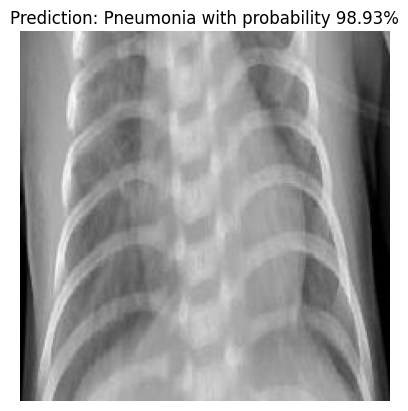


Generating Grad-CAM...


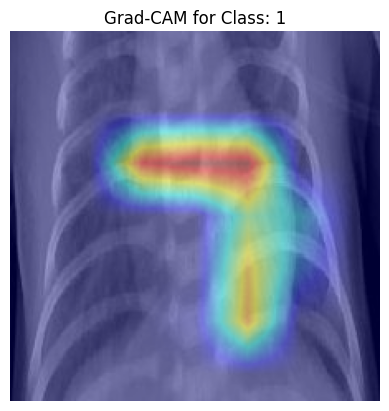

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow.keras.models import Model
from tensorflow.keras.utils import load_img, img_to_array

def load_model(model_path):
    """Load the trained model."""
    return tf.keras.models.load_model(model_path)

def preprocess_image(image_path, target_size=(224, 224)):
    """Preprocess a single image."""
    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img) / 255.0  # Normalize to [0, 1]
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img, img_array

def predict_single_image(model, image_path, class_names):
    """Predict the class of a single image."""
    img_original, img_array = preprocess_image(image_path)

    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)
    confidence = predictions[0][predicted_class] * 100

    result_text = f"Prediction: {class_names[predicted_class]} with probability {confidence:.2f}%"
    print(result_text)

    # Display the image with prediction
    plt.imshow(img_original)
    plt.title(result_text)
    plt.axis("off")
    plt.show()

def display_gradcam(model, image_path, class_idx, layer_name):
    """Generate and display Grad-CAM for a single image."""
    # Preprocess the image
    img_original, img_array = preprocess_image(image_path)

    # Create a model mapping input to activations of the chosen layer and output predictions
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    # Compute the gradient of the class output with respect to the feature map
    with tf.GradientTape() as tape:
        inputs = tf.convert_to_tensor(img_array)  # Use the image array directly
        conv_outputs, predictions = grad_model(inputs)
        loss = predictions[:, class_idx]  # Focus on the desired class output

    # Compute the gradients of the loss w.r.t. the output feature map
    grads = tape.gradient(loss, conv_outputs)[0]
    grads = tf.maximum(grads, 0)  # ReLU for positive gradients
    grads /= tf.reduce_max(grads) + 1e-8  # Normalize gradients

    # Weighted sum of feature map
    weights = tf.reduce_mean(grads, axis=(0, 1))  # Global average pooling on gradients
    cam = np.dot(conv_outputs[0], weights.numpy())  # Weighted sum

    # Normalize CAM
    cam = np.maximum(cam, 0)
    cam = cam / (np.max(cam) + 1e-8)

    # Resize heatmap to match original image size
    heatmap = cv2.resize(cam, (img_original.size[0], img_original.size[1]))
    heatmap = (heatmap * 255).astype("uint8")
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay heatmap on the original image
    overlay = cv2.addWeighted(cv2.cvtColor(np.array(img_original), cv2.COLOR_RGB2BGR), 0.6, heatmap, 0.4, 0)

    # Display the Grad-CAM overlay
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"Grad-CAM for Class: {class_idx}")
    plt.axis("off")
    plt.show()

def main():
    model_path = r"C:\Users\Legion\Desktop\pneumo\resnet50\model\ResNet50_Pneumo.keras"
    #single_image_path = r"C:\Users\Legion\Desktop\pneumo\data\processed\train\NORMAL\NORMAL2-IM-1295-0001.jpeg"  # Update with a test image path
    single_image_path = r"C:\Users\Legion\Desktop\pneumo\data\processed\train\PNEUMONIA\person342_virus_702.jpeg"  # Update with a test image path
    class_names = ["Normal", "Pneumonia"]

    # Load the model
    print("Loading the model...")
    model = load_model(model_path)

    # Predict on a single image
    print("\nTesting prediction on a single image...")
    predict_single_image(model, single_image_path, class_names)

    # See a sum of the model
    #model.summary()

    # Display Grad-CAM
    print("\nGenerating Grad-CAM...")
    # Change the class index as u need 1 = visualise the virus 0 otherwise
    display_gradcam(model, single_image_path, class_idx=1, layer_name="conv5_block3_3_conv")  # Update layer name if needed


if __name__ == "__main__":
    main()
